[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aarondomenzain/tracking-softmatter-aarond/blob/tracking-softmatter-aarond-dev/tutorial/detection/detection_core-shell.ipynb)

# Particle Tracking Tutorial: Particle Detection and Localization

In this tutorial, you’ll explore different methods to detect and localize particles in microscopy images using both simulated data and real experimental images.

You’ll start by generating a simulated image of microscopic particles, mimicking what you might see in a soft matter or biophysics experiment. Since you know the true particle positions in the simulation (i.e., the 'ground truth'), you can directly evaluate how well each detection method performs.

Here’s what you’ll test and compare:

- Thresholding and Connected Components

- Crocker and Grier (using TrackPy — a classic in particle tracking)

- U-Net (a neural network for image segmentation)

- LodeSTAR (a self-supervised deep learning method)

You’ll be using Python libraries like NumPy, SciPy, Matplotlib, scikit-image, PyTorch, DeepTrack, and Deeplay. 

## Table of Contents

0. [Import the Required Libraries and Load Utility Functions](#import-the-required-libraries-and-load-utility-functions)
1. [Load and Visualize Experimental Images](#load-and-visualize-experimental-images)
2. [Simulate Realistic Images with DeepTrack](#simulate-realistic-images-with-deeptrack)
    - [Simulate a Single Particle](#simulate-a-single-particle)
    - [Simulate a Test Image to Benchmark Detection Methods](#simulate-a-test-image-to-benchmark-detection-methods)
3. [Method 1: Thresholding and Connected Components](#3-method-1-thresholding-and-connected-components)
    - [Apply Intensity Thresholding](#apply-intensity-thresholding)
    - [Determine Centroids with Connected Components Analysis](#determine-centroids-with-connected-components-analysis)
    - [Evaluate the Performance of the Method](#evaluate-the-performance-of-the-method)
      - [Refine Localization](#refine-localization)
    - [Apply the Method to Experiments](#apply-the-method-to-experiments)

4. [Method 2: Crocker and Grier](#method-2-crocker-and-grier)
    - [Estimate Particle Size from Simulations](#estimate-particle-size-from-simulations)
    - [Apply the Crocker and Grier Method to Simulations](#apply-the-crocker-and-grier-method-to-simulations)
    - [Apply the Crocker and Grier Method to Experiments](#apply-the-crocker-and-grier-method-to-experiments)

5. [Method 3: U-Net](#method-3-u-net)
    - [Create a Training Dataset](#create-a-training-dataset)
    - [Define a U-Net Model with Deeplay](#define-a-u-net-model-with-deeplay)
    - [Train the U-Net model](#train-the-u-net-model)
    - [Apply the Trained U-Net to the Simulations](#apply-the-trained-u-net-to-simulations)
    - [Apply the Trained U-Net to the Experiments](#apply-the-trained-u-net-to-experiments)

6. [Method 4: LodeSTAR](#method-4-lodestar)
    - [Simulate Training Data for LodeSTAR](#simulate-training-data-for-lodestar)
    - [Train LodeSTAR and Apply it to Simulations](#train-lodestar-and-apply-it-to-simulations)
    - [Apply the Trained LodeSTAR to Experiments](#apply-the-trained-lodestar-to-experiments)
    - [Train LodeSTAR with Experiments](#train-lodestar-with-experimentas)

## Import the Required Libraries and Load Utility Functions

Uncomment the next cell if running on Google Colab/Kaggle.

In [328]:
#!pip install deeptrack deeplay trackpy -q

Import required libraries.

In [329]:
# Standard libraries
import os
import random
import sys

# Core Scientific Stack
import numpy as np
import scipy

# Plotting and Display
import matplotlib.pyplot as plt

# Machine Learning
import deeplay as dl
import torch

# Particle Tracking and Simulation
import deeptrack as dt
import trackpy as tp

# Image Analysis
import skimage  # Image analysis (scikit)

Load a set of custom functions defined specifically for this notebook from the `utils` directory. For detailed documentation of each function, refer to the comments and docstrings within the files.

In [330]:
# Load functions and utilities for dataset generation and visualization.
# Sys append a folder to the path.
sys.path.append(os.path.abspath(os.path.join("..", "..")))

# Import all the functions contained in the folder utils.
import utils

Set random seeds to make results reproducible across runs, especially during training and data simulation.

In [331]:
# Set a fixed seed value.
seed = 89

# Python, NumPy, and PyTorch (CPU).
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Only set CUDA seeds if a GPU is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Seeds set to {seed} (with CUDA: {torch.cuda.is_available()})")

# Get the best available device for Torch computation.
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Seeds set to 89 (with CUDA: True)
Using CUDA GPU: NVIDIA GeForce RTX 5090


## Load and Visualize Experimental Images

Load a `.tif` image from the `images/` folder and display it using scikit-image.

Selected file: images\MR16.89_11_10837.tif


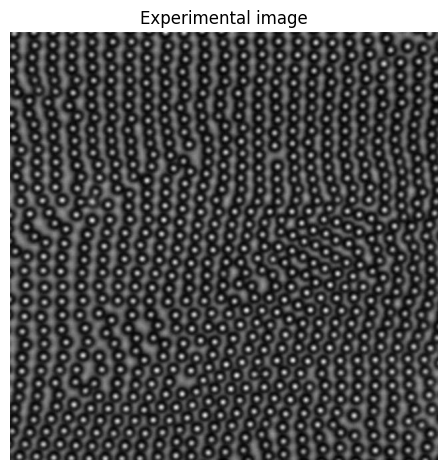

Size of imported image in pixels: 640


In [332]:
# Define the folder and image file name.
image_folder = "images"
image_file_name =  "MR16.89_11_10837.tif"

# Construct the full path.
image_path = os.path.join(image_folder, image_file_name)

# Create an instance of the loaded file using SciKit.
exp_image = skimage.io.imread(image_path)

# Crop the image to a square. 
exp_image = exp_image[:640, :640, 0]

# Get the shape of the image.
assert exp_image.shape[0] == exp_image.shape[1], "Warning: Image not square!"
exp_image_size = exp_image.shape[0]

# Print the name of the selected file.
print("Selected file:", image_path)

# Open a figure instance.
plt.figure()

# Plot the image in grayscale.
plt.imshow(exp_image, cmap="gray")
plt.axis("off")
plt.title("Experimental image")
plt.tight_layout()
plt.show()

# Print the image size in pixels.
print(f"Size of imported image in pixels: {exp_image_size}")

Manually select and display a single particle by specifying its centroid coordinates (x,y) and a box width.

**Note:** Images in NumPy are indexed as `(column, row)`, which corresponds to (y, x) in Cartesian coordinates.

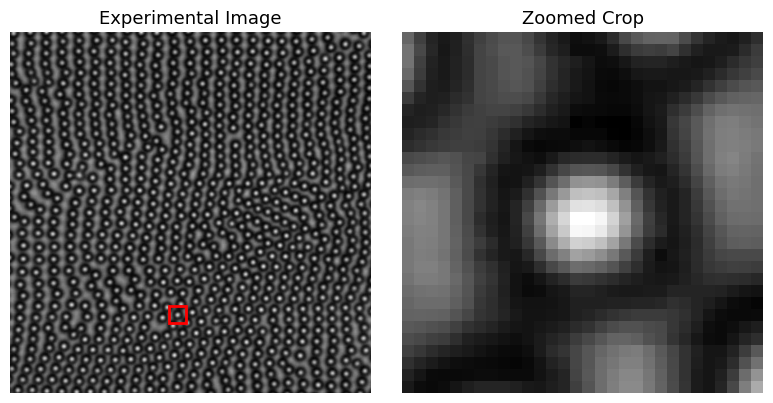

In [333]:
from matplotlib.patches import Rectangle

# Window size to zoom in an individual particle.
exp_crop_size = 30

# Coordinates of the center of the particle.
x_center, y_center = 297, 501

# Compute crop bounds.
x_min = x_center - exp_crop_size // 2
x_max = x_center + exp_crop_size // 2
y_min = y_center - exp_crop_size // 2
y_max = y_center + exp_crop_size // 2

# Extract crop (note: rows = y, cols = x)
exp_crop = exp_image[y_min:y_max, x_min:x_max]

# Create a single figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Left panel: full image with square window.
axes[0].imshow(exp_image, cmap="gray")
axes[0].set_title("Experimental Image", fontsize=13)
axes[0].add_patch(
    Rectangle(
        (x_min, y_min), exp_crop_size, exp_crop_size,
        edgecolor='red', facecolor='none', linewidth=2,
    )
)
axes[0].axis("off")

# Right panel: zoomed-in crop
axes[1].imshow(exp_crop, cmap="gray")
axes[1].set_title("Zoomed Crop", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Simulate Realistic Images with DeepTrack

DeepTrack allows you to simulate physically realistic microscopy images, enabling precise control over imaging parameters and particle properties. These simulations provide ground-truth data, making them ideal for benchmarking classical and AI-based tracking methods, as well as for training neural networks in a controlled environment.

### Simulate a Single Particle

Adjust the simulation parameters to accurately replicate the features observed in the cropped region of the experimental image.

c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\deeptrack\optical\optics.py:1418: UserWarning: Scatterer defines 'refractive_index', which is ignored in fluorescence microscopy.
  warnings.warn(


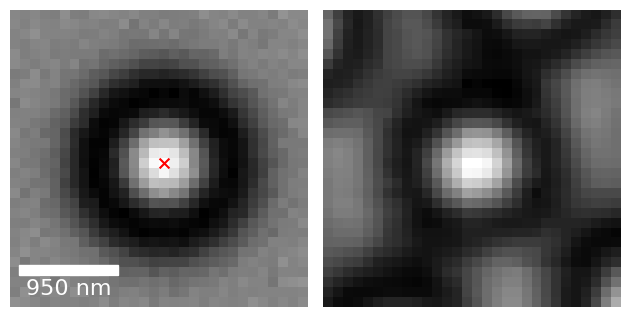

In [334]:
# Same as when selecting a single object.
sim_crop_size = exp_crop_size  

# Size of a pixel in nanometers in the output image.
pixel_size_nm = 95  # In nm

# Radius of the spherical scatterer in nm.
radius = 430   # In nm

# Define central spherical scatterer
inner_sphere = dt.Sphere(
    position=lambda: 0.5 * np.array([sim_crop_size, sim_crop_size]),
    z= 0 * dt.units.nm,  # Particle in focus
    radius=radius * dt.units.nm,  # Radius in nm
    intensity= 1450,
    refractive_index=1.59,  # Polystyrene 
)

# Define a surrounding shell
outer_sphere = dt.Sphere(
    position=inner_sphere.position,  # Same position as the inner sphere
    radius=inner_sphere.radius * 2.3,  # Outer sphere bigger than inner sphere
    inner_intensity=inner_sphere.intensity,
    intensity= -300,
    refractive_index=1.5 # PVA
)

# Instance containing the core + shell spheres.
combined_sphere = inner_sphere >> outer_sphere

# Simulate the properties of the fluorescence microscope.
optics = dt.Fluorescence(
    NA=0.6,  # Numerical aperture
    wavelength=638 * dt.units.nm, 
    refractive_index_medium=1.33, 
    output_region=[0, 0, sim_crop_size, sim_crop_size],
    magnification=1,
    resolution=pixel_size_nm * dt.units.nm,  # Camera effective resolution
)

# Apply transformations: combine spheres, scale, add noise, and apply Gaussian
# filter.
sim_crop = (
    optics(combined_sphere)
    >> dt.Background(100)
    >> dt.Poisson(snr=600)
)

# Turn the crop into a NumPy array.
sim_crop = np.squeeze(sim_crop())

# Plot the simulated and experimental crops.
fig, axes = plt.subplots(1, 2)

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

pixel_size_scalebar = 10
scalebar_length = pixel_size_scalebar * pixel_size_nm 

scalebar = AnchoredSizeBar(
    axes[0].transData,
    pixel_size_scalebar,   # Length in pixels
    f"{scalebar_length} nm",
    "lower left",
    pad=0.3,
    color="white",
    frameon=False,
    size_vertical=1,
    fontproperties=fm.FontProperties(size=16),
)

axes[0].add_artist(scalebar)

# Simulated crop.
axes[0].imshow(sim_crop, cmap="gray")
axes[0].axis("off")
axes[0].scatter([sim_crop_size / 2], [sim_crop_size / 2], color="red", s=50, marker="x")
#axes[0].set_title("Simulated Crop")

# Experimental crop.
axes[1].imshow(exp_crop, cmap="gray")
axes[1].axis("off")
#axes[1].set_title("Experimental Crop")

# Adjust layout and show plot.
plt.tight_layout()
plt.show()

Extract and visualize the raw intensity profiles along the central horizontal and vertical lines of both the simulated and experimental crops. This comparison helps evaluate how well the simulation reproduces the intensity distribution observed in real microscopy images.

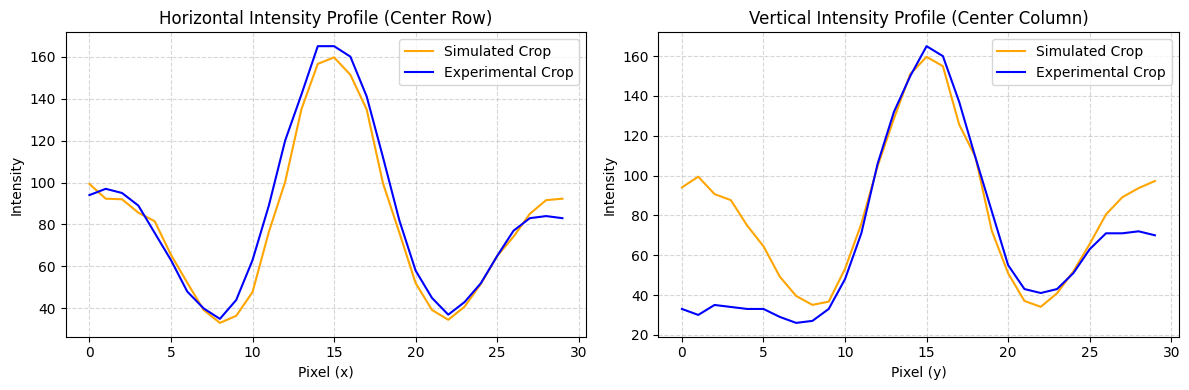

In [335]:
# Compute the center index.
center = sim_crop_size // 2

# Extract horizontal (row) profiles.
sim_horiz = sim_crop[center, :]
exp_horiz = exp_crop[center, :]

# Extract vertical (column) profiles.
sim_vert = sim_crop[:, center]
exp_vert = exp_crop[:, center]

# Create a 1×2 subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

# --- Horizontal profile ---
axes[0].plot(sim_horiz, label="Simulated Crop", color="orange")
axes[0].plot(exp_horiz, label="Experimental Crop", color="blue")
axes[0].set_xlabel("Pixel (x)")
axes[0].set_ylabel("Intensity")
axes[0].set_title("Horizontal Intensity Profile (Center Row)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- Vertical profile ---
axes[1].plot(sim_vert, label="Simulated Crop", color="orange")
axes[1].plot(exp_vert, label="Experimental Crop", color="blue")
axes[1].set_xlabel("Pixel (y)")
axes[1].set_ylabel("Intensity")
axes[1].set_title("Vertical Intensity Profile (Center Column)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

A radial intensity profile can also offer valuable information in the case of spherical particles, by integrating the intensity along the angular coordinate.

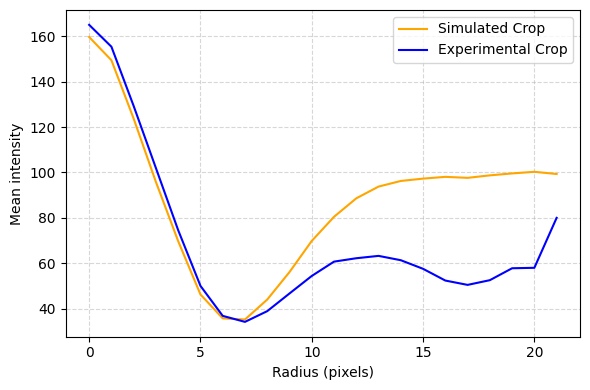

In [336]:
# Compute radial intensity profiles.
def radial_profile(image):
    image = np.asarray(image)

    y, x = np.indices(image.shape)
    center = np.array(image.shape) // 2

    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(int)

    radial_sum = np.bincount(r.ravel(), image.ravel())
    radial_count = np.bincount(r.ravel())

    return radial_sum / radial_count

# Compute profiles.
sim_radial = radial_profile(sim_crop)
exp_radial = radial_profile(exp_crop)

# Radial coordinate.
radius = np.arange(len(sim_radial))

# Plot.
plt.figure(figsize=(6, 4))

plt.plot(radius, sim_radial, label="Simulated Crop", color="orange")
plt.plot(radius, exp_radial, label="Experimental Crop", color="blue")

plt.xlabel("Radius (pixels)")
plt.ylabel("Mean intensity")
#plt.title("Radial Intensity Profile")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Note:**  Deviations in intensity far from the center in the experimental image are due to proximity with neighbouring particles, breaking the radial symmetry.

### Simulate a Test Image to Benchmark Detection Methods

Create a simulated image containing non-overlapping spherical particles. Begin by generating their coordinates—these will serve as the ground-truth positions. Then, use DeepTrack to render optically realistic particles at these coordinates, resulting in a physically plausible microscopy image.

In [337]:
# Parameters of the simulation.
sim_image_size = 640  # Size of the simulated image in pixels
N_particles = 1000  # Number of particles in the simulated image
core_radius = 430  # Core particle radius in nm
shell_radius = core_radius * 1.8  # Outer shell must be bigger than core

# Total radius.
particle_radius = np.maximum(core_radius, shell_radius)

# Dictionaries for shell and core properties. Dimensions are set with lambda
# functions to introduce variety to the dataset.
core_particle_properties={
    "radius": lambda: (
        np.random.uniform(0.95, 1.0) * core_radius * dt.units.nm
    ),
    "intensity": lambda: np.random.uniform(900, 1050),
    "z": lambda: np.random.normal(0, 30) * dt.units.nm,  # Particle in focus
    "refractive_index": 1.59  # Polystyrene
}

shell_particle_properties={
    "radius": lambda: np.random.uniform(0.95, 1.0) * shell_radius * dt.units.nm,
    "intensity": lambda: np.random.uniform(-200, -250),
    "refractive_index": 1.5  # PVA
}

# Set the optical properties of the microscope.
optics_properties = dt.Fluorescence(
    NA=0.6,  # Numerical aperture
    wavelength=638 * dt.units.nm, 
    refractive_index_medium=1.33, 
    output_region=[0, 0, sim_image_size, sim_image_size],
    magnification=1,
    resolution=pixel_size_nm * dt.units.nm,  # Camera effective resolution
)

# Generate ground truth positions.
sim_locs_gt = utils.generate_centroids(
    num_particles=N_particles,
    fov_size=sim_image_size,
    particle_radius=particle_radius,
)

# Simulate image.
sim_image = utils.transform_to_video(
    sim_locs_gt,
    fov_size=sim_image_size,
    core_particle_props=core_particle_properties,
    shell_particle_props=shell_particle_properties,
    optics_props=optics_properties,
    background_props={"poisson_snr": 200, "background_mean": 30, "std": 50},
)

# Generate the ground truth as Gaussian clouds centered at the position of the
# spheres. The standard deviation of the Gaussians are set to be proportional 
# to the radii of the corresponding spherical particles.
gt_cloud_size = particle_radius / 3

# Generate ground truth map using the positions, radii and intensities of the 
# particles.
sim_map = utils.create_ground_truth_map(
    sim_locs_gt, 
    fov_size=sim_image_size, 
    sigma=gt_cloud_size, 
)

Visualize the simulated image and compare it with the experimental one.

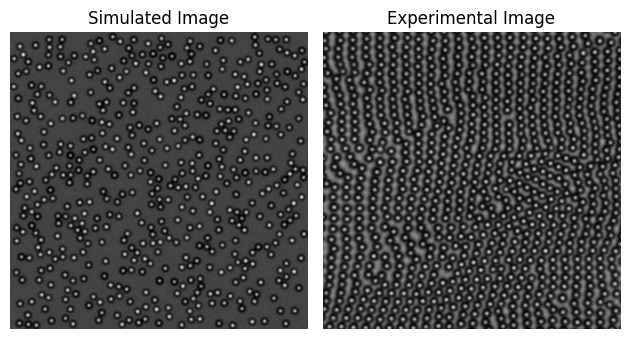

In [338]:
# Plot the simulated and experimental images.
fig, axes = plt.subplots(1, 2)

# Simulated image.
plot = axes[0].imshow(sim_image, cmap="gray")
axes[0].axis("off")
axes[0].set_title("Simulated Image")

# Experimental image.
axes[1].imshow(exp_image, cmap="gray")  
axes[1].axis("off")
axes[1].set_title("Experimental Image")

# Adjust layout and show plot.
plt.tight_layout()
plt.show()

Perform a more quantitative comparison by plotting the intensity histograms.

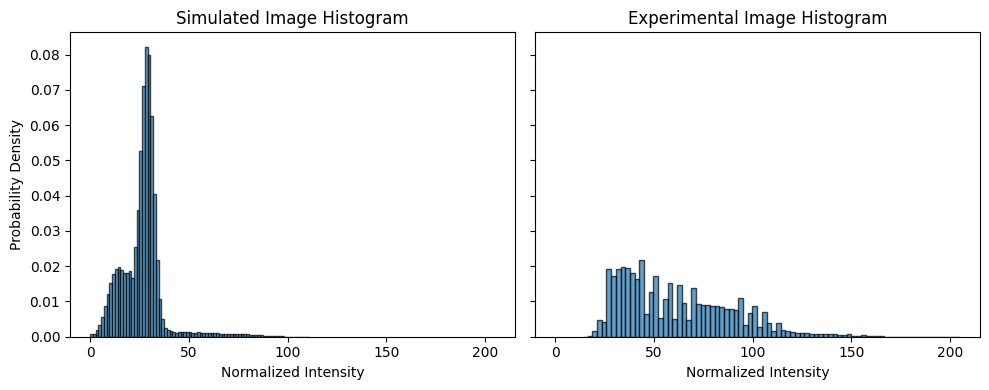

In [339]:
# Flatten the arrays to 1D.
sim_vals = sim_image.ravel()
exp_vals = exp_image.ravel()

# Create figure with two subplots sharing the y-axis.
fig, axes = plt.subplots(
    1, 2, figsize=(10, 4), sharey=True, sharex=True, tight_layout=True,
)

# Histogram for simulated image.
axes[0].hist(sim_vals, bins=80, alpha=0.7, edgecolor="black", density=True)
axes[0].set_title("Simulated Image Histogram")
axes[0].set_xlabel("Normalized Intensity")
axes[0].set_ylabel("Probability Density")

# Histogram for experimental image.
axes[1].hist(exp_vals, bins=80,  alpha=0.7, edgecolor="black", density=True)
axes[1].set_title("Experimental Image Histogram")
axes[1].set_xlabel("Normalized Intensity")
# No need to set ylabel on the second axes when sharing.

plt.show()

**Note:** The simulated image has less particles compared to the experimental one. These differences are visible in the histogram but the dynamic range is rather similar.

Visualize the simulated image and the corresponding ground truth map. Each particle has an associated ground truth cloud with a Gaussian profile, whose standard deviation is proportional to the radius of the particle.

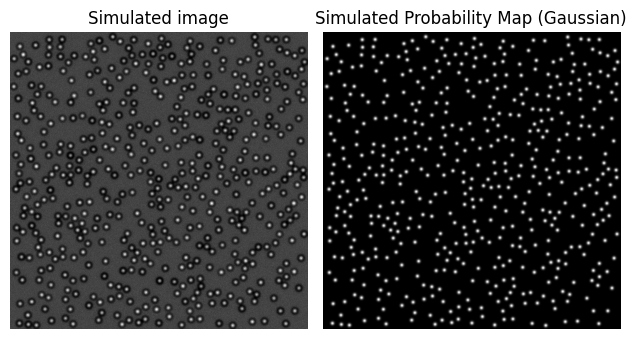

In [340]:
# Create a subfigure instance to plot the image and the probability map.
fig, ax = plt.subplots(1, 2)

# Instance for the simulated experimental image. 
img1 = ax[0].imshow(sim_image, cmap="gray")
ax[0].axis("off")
ax[0].set_title("Simulated image")  

# Instance for the probability map.
img2 = ax[1].imshow(sim_map, cmap="gray")
ax[1].axis("off")
ax[1].set_title("Simulated Probability Map (Gaussian)") 

# Adjust layout to avoid overlap.
plt.tight_layout()

# Show the plot.
plt.show()

From now on, you'll use normalized images.

In [341]:
# Normalize the images to the range [0, 1].
exp_image = utils.normalize_min_max(
    exp_image, minimum_value=0.0, maximum_value=1.0,
)
sim_image = utils.normalize_min_max(
    sim_image, minimum_value=0.0, maximum_value=1.0,
)

## Method 1: Thresholding and Connected Components

In a grayscale image, each pixel has an intensity value, where higher values typically indicate the presence of particles while lower values represent the background (but it can also be the other way around).

A simple and effective method for particle detection is **intensity thresholding**, which converts the grayscale image into a binary mask. Pixels with intensities above a chosen threshold are marked as foreground (set to 1, corresponding to white), and the rest as background (set to 0, corresponding to black).

If particles appear darker than the background—as in absorption-based or negative stain imaging—the threshold should instead be applied to the lower end of the intensity distribution.

After thresholding, **connected component analysis** can be used to label and isolate individual foreground regions. Each connected component represents a candidate particle, enabling basic localization by computing properties such as the centroid (position), area (size), or bounding box (extent) of each region.

### Apply Intensity Thresholding 

A robust way to choose the threshold is to use the **intensity quantile**. For example, setting the threshold at the 90th percentile selects the brightest 10% of pixels, which often correspond to particles. This method is more reliable than using the image mean and standard deviation, which can be biased by background-dominated images.

Before thresholding, it’s a good idea to smooth the image with a Gaussian filter. This helps suppress noise and small fluctuations that aren’t real particles.

In [342]:
# Apply a Gaussian filter to the image to smooth out noise.
filtered_sim_image = scipy.ndimage.gaussian_filter(sim_image, sigma=1.5)

Plot the intensity histogram of the simulated image before and after Gaussian filtering.

Intensity threshold (quantile=97%): 0.416297281681773


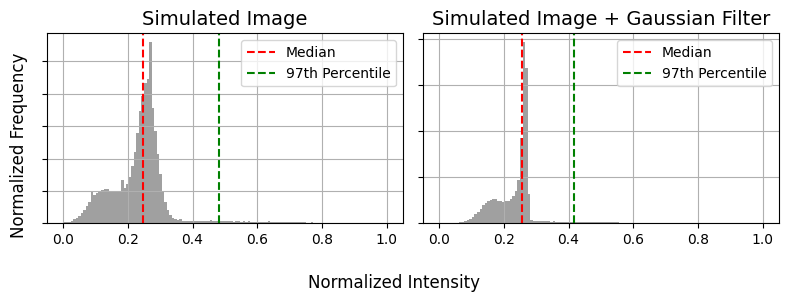

In [343]:
# Define the quantile level (e.g., 97% selects the top 3% brightest pixels).
quantile_level = 0.97

# Compute statistics
median_intensity_sim = np.median(sim_image)
quantile_threshold_sim = np.quantile(sim_image, quantile_level)

median_intensity_filtered_sim = np.median(filtered_sim_image)
quantile_threshold_filtered_sim = np.quantile(filtered_sim_image, quantile_level)

print(f"Intensity threshold (quantile={quantile_level*100:.0f}%): "
      f"{quantile_threshold_filtered_sim}")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Histogram for simulated image
axes[0].hist(sim_image.flatten(), bins=128, range=(0, 1), color="gray",
             alpha=0.75, density=True)
axes[0].axvline(median_intensity_sim, color="red", linestyle="dashed",
                linewidth=1.5, label="Median")
axes[0].axvline(quantile_threshold_sim, color="green", linestyle="dashed",
                linewidth=1.5, label=f"{int(quantile_level*100)}th Percentile")
axes[0].set_title("Simulated Image", fontsize=14)
axes[0].set_yticklabels([])  # Remove y labels
axes[0].legend()
axes[0].grid(True)

# Histogram for filtered image
axes[1].hist(filtered_sim_image.flatten(), bins=128, range=(0, 1),
             color="gray", alpha=0.75)
axes[1].axvline(median_intensity_filtered_sim, color="red", linestyle="dashed",
                linewidth=1.5, label="Median")
axes[1].axvline(quantile_threshold_filtered_sim, color="green",
                linestyle="dashed", linewidth=1.5,
                label=f"{int(quantile_level*100)}th Percentile")
axes[1].set_title("Simulated Image + Gaussian Filter", fontsize=14)
axes[1].set_yticklabels([])
axes[1].legend()
axes[1].grid(True)

# Set common x and y labels
fig.supxlabel("Normalized Intensity", fontsize=12)
fig.supylabel("Normalized Frequency", fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

Apply the threshold to generate a binary mask, then display it together with the original image for visual validation.

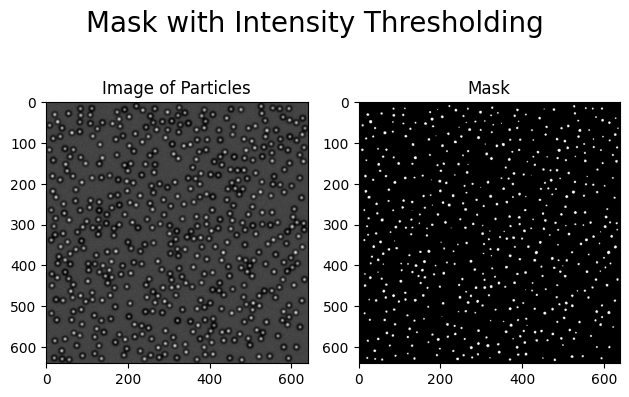

In [344]:
# Create the binary mask by applying the threshold.
sim_mask = filtered_sim_image > quantile_threshold_filtered_sim

# Ensure the mask is a 2D array.
sim_mask = np.squeeze(sim_mask)

# Plot the image with the calculated mask.
utils.plot_image_mask_ground_truth_map(
    image=sim_image, 
    mask=sim_mask, 
    title="Mask with Intensity Thresholding",
)

### Determine Centroids with Connected Components Analysis

Detect objects from the binary mask and extract their centroids using the scikit-image library. This is typically done by identifying connected components and computing their center of mass, which provides an estimate of each particle’s position.

In [345]:
# Use the function to extract positions from mask.
sim_locs_pred_method1 = utils.mask_to_positions(sim_mask)
print(f"Found {len(sim_locs_pred_method1[:,1])} detections.")

Found 519 detections.


Plot the extracted centroids on top of the image.

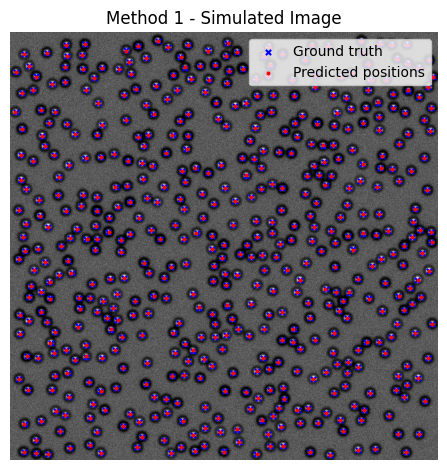

In [346]:
# Use the plotting function to compare the detection with the ground truth.
utils.plot_predicted_positions(
    image=sim_image, 
    pred_positions=sim_locs_pred_method1, 
    gt_positions=sim_locs_gt, 
    title="Method 1 - Simulated Image",
)

### Evaluate the Performance of the Method

Apply the `evaluate_locs` function that calculates evaluation metrics and print them. It calculates True Positives (TP), False Positives (FP), False Negatives (FN), F1 score (F1), and Root Mean Square Error (RMSE).

In [347]:
TP, FP, FN, F1, RMSE = utils.evaluate_locs(
    sim_locs_pred_method1,sim_locs_gt, distance_th=particle_radius
)

True Positives: 519/519
False Positives: 0
False Negatives: 0
F1 Score: 1.0000
RMSE: 0.1471


#### Refine Localization

You can imporve localization precision by passing the raw image into `mask_to_positions()`. This function uses the actual gray‐level intensities within each connected component to compute a weighted centroid, giving you subpixel‐refined coordinates.

Use weighted centroid refinement to achieve more accurate centroid positions.

In [348]:
# Estimate the location of the centroid of a masked particle image.
sim_locs_pred_method1_ref = \
    utils.mask_to_positions(sim_mask, sim_image.squeeze())

# Evaluate the performance.
TP, FP, FN, F1, RMSE = utils.evaluate_locs(
    sim_locs_pred_method1_ref, sim_locs_gt, distance_th=particle_radius,
)

True Positives: 519/519
False Positives: 0
False Negatives: 0
F1 Score: 1.0000
RMSE: 0.1280


### Apply the Method to Experiments

Apply the same method to the experimental image:

- Smooth the image using a Gaussian filter.
- Choose a threshold.
- Create a binary mask where pixels above the threshold are marked as potential particles.
- Extract positions from the mask.
- Plot both the predicted positions and the mask for visual inspection.
- Print the number of detections found.

This gives us a first estimate of particle positions using just thresholding—no machine learning needed!

No ground truth positions were passed


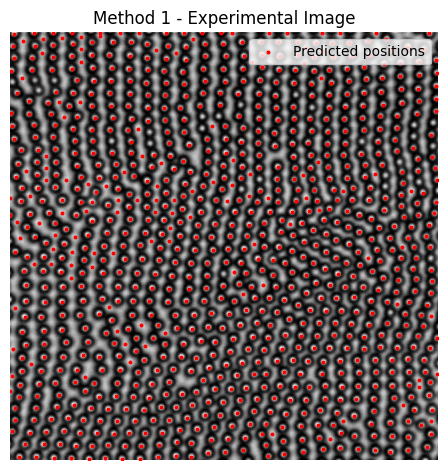

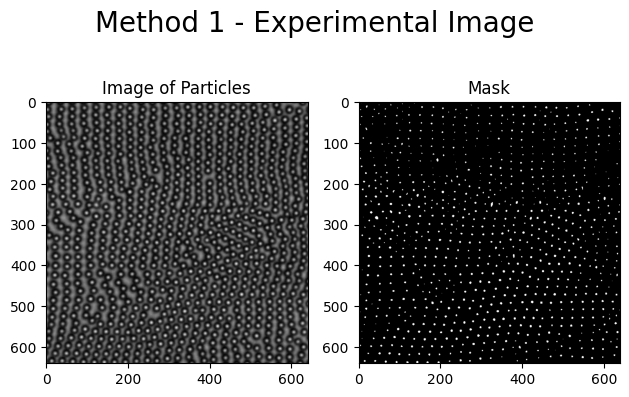

Found 911 detections.


In [349]:
# Apply a Gaussian filter to the image to smooth out noise.
filtered_exp_image = scipy.ndimage.gaussian_filter(exp_image, sigma=1.0)

# quantile level for thresholding.
quantile_level = 0.97

# Intensity threshold for the experimental image.
quantile_threshold_filtered_exp = \
    np.quantile(filtered_exp_image, quantile_level)

# Create the binary mask by applying the threshold.
exp_mask = filtered_exp_image > quantile_threshold_filtered_exp

# Get predicted positions from the mask.
exp_locs_pred_method1 = utils.mask_to_positions(exp_mask, exp_image)

# Plot the experimental image with the predicted positions.
utils.plot_predicted_positions(
    image=exp_image,
    pred_positions=exp_locs_pred_method1,
    title="Method 1 - Experimental Image",
)

# Plot the experimental image and the mask.
utils.plot_image_mask_ground_truth_map(
    image=exp_image, 
    mask=exp_mask, 
    title="Method 1 - Experimental Image",
)

# Print the number of detections.
print(f"Found {len(exp_locs_pred_method1[:,1])} detections.")

## Method 2: Crocker and Grier (TrackPy)

A refined approach for particle detection and localization is the Crocker and Grier method. This method identifies local intensity maxima and refines their positions by fitting the surrounding region to a Gaussian-like profile. It offers subpixel accuracy and performs well even in moderately noisy conditions or crowded images.

TrackPy provides a built-in implementation of the Crocker and Grier particle detection method.

### Estimate Particle Size from Simulations

In the TrackPy implementation of the Crocker and Grier method, the primary parameter you need to set is the estimated particle size, which must be an odd number.

To estimate this value, inspect the simulated image interactively: click on both edges of a representative particle to measure its approximate width. Keep in mind that particle sizes may vary across the image, so this should be treated as an initial guess. You can refine the diameter later by evaluating the quality of the detections.

**Note:** For the interactive widget to work correctly, you might need to install `ipykernel` manually, for example using:
```bash
pip install ipykernel
```

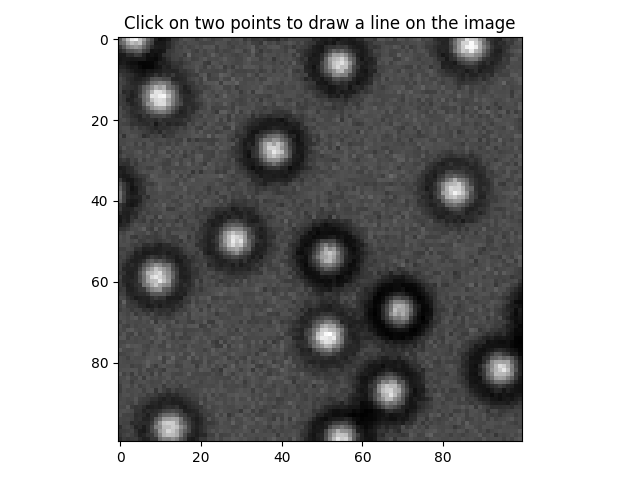

In [350]:
# Set the matplotlib interactive backend .
%matplotlib widget
utils.interactive_ruler(sim_image[250:350, 250:350])

Switch the backend back to the default, where plots are rendered as static images in the notebook cells.

In [351]:
# Close the figure so it doesn't re-render
plt.close("all")

# Switch back to static plots
%matplotlib inline

### Apply the Crocker and Grier Method to Simulations

Use `trackpy.locate()` to detect particles in the image. This function returns a DataFrame object containing the coordinates of the detected particles along with various feature properties.

Extract the (x, y) positions from the DataFrame and compare them to the ground truth coordinates to assess the accuracy of the detection.

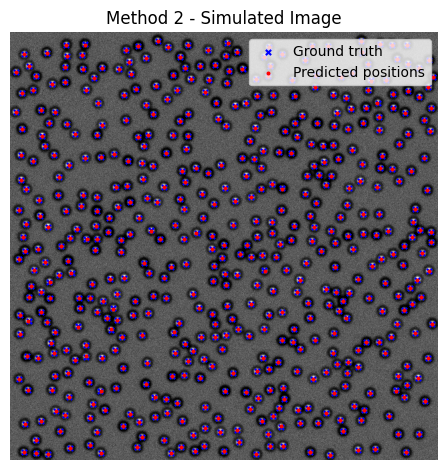

True Positives: 519/519
False Positives: 0
False Negatives: 0
F1 Score: 1.0000
RMSE: 0.0805


In [352]:
# Estimate and tune the diameter of particles in pixels, ensuring it is an
# odd number. Adjust if necessary.
estimated_size_sim = 13

# Use the locate built-in function from TrackPy.
# Output is type DataFrame([x, y, mass, size, ecc, signal, raw_mass]).
df_sim_locs_pred_method2 = tp.locate(
    sim_image, 
    diameter=estimated_size_sim,
    noise_size=3,  # Setting for denoising image
)

# Extract the predicted positions from DataFrame["x","y"] into a NumPy array.
sim_locs_pred_method2 = np.array(df_sim_locs_pred_method2)[:,:2]

# Plot the prediction and the ground truth.
utils.plot_predicted_positions(
    image=sim_image,
    pred_positions=sim_locs_pred_method2,
    gt_positions=sim_locs_gt,
    title="Method 2 - Simulated Image",
)

# Evaluate the performance of tp.locate.
utils.evaluate_locs(
    sim_locs_pred_method2,
    sim_locs_gt,
    distance_th=particle_radius,
);

### 

### Apply the Crocker and Grier Method to Experiments

Interactively estimate particle size.

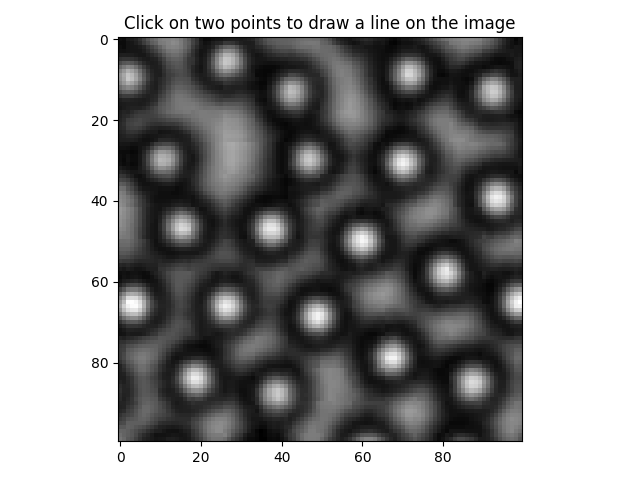

In [353]:
# Set the matplotlib interactive backend .
%matplotlib widget
# Plot a small ROI of the experimental image.
utils.interactive_ruler(exp_image[350:450, 350:450])

Switch the backend back to the default, where plots are rendered as static images in the notebook cells.

In [354]:
# Close the figure so it doesn't re-render
plt.close("all")

# Switch back to static plots
%matplotlib inline

No ground truth positions were passed


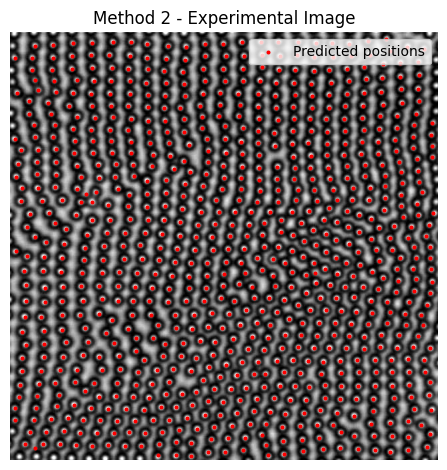

Found 792 detections.


In [355]:
# Adjust the estimated diameter if necessary. 
estimated_size_exp = 13

# Use trackpy.locate to experimental data file 'image'.
df_exp_locs_pred_method2 = tp.locate(
    exp_image, 
    diameter=estimated_size_exp,
    noise_size=4, # Setting for denoising image.

)

# Extract the predicted positions from DataFrame["x","y"] into a NumPy array.
exp_locs_pred_method2 = np.array(df_exp_locs_pred_method2)[:,:2]

# Plot the experimental image with predicted positions overlaid.
utils.plot_predicted_positions(
    image=exp_image,
    pred_positions=exp_locs_pred_method2,
    title="Method 2 - Experimental Image",
)

print(f"Found {len(exp_locs_pred_method2[:, 1])} detections.")

## Method 3: U-Net

The U-Net is a convolutional neural network (CNN) widely used for image segmentation tasks. It performs pixel-wise classification, enabling precise separation between background and objects of interest—ranging from simple particles to complex cells or anatomical structures, depending on the training data.

In the context of particle detection, U-Net can be trained to map input microscopy images directly into **probability distributions** that represent the likelihood of a particle being present at each pixel. Instead of assigning a hard classification (particle or background), the network outputs a **dense probability map**—a soft, continuous prediction indicating how likely each pixel is to belong to a particle. This approach is particularly useful in challenging scenarios, such as overlapping particles—where discrete detection may fail—or small, faint particles that traditional methods might miss.

Once trained, U-Net generalizes to new images, producing smooth probability maps that can be thresholded to create binary masks for downstream connected-component analysis. For localization, these maps enable the calculation of **intensity-weighted centroids**, allowing subpixel resolution of particle positions and improving localization accuracy. Alternatively, the maps can be analyzed using peak detection algorithms or interpreted as confidence scores to filter or rank detections.

### Create a training dataset

U-Net is trained using pairs of input images and corresponding target maps, which represent the expected output distribution. These target maps typically consist of Gaussian blobs centered at the true particle locations, encoding both position and uncertainty.

To generate training data, you can simulate particle images using DeepTrack, along with their associated probability maps to serve as ground truth.

If a dataset has already been generated and saved, you can simply load it and skip the simulation step.

In [356]:
# Number of samples, image size, and particles.
num_samples = 128
train_image_size = 128
max_num_particles = 50
force_simulation = True  # Flag to force simulation even if data exists.

# Set the optical properties of the microscope.
optics_properties = dt.Fluorescence(
    NA=0.6,  # Numerical aperture
    wavelength=638 * dt.units.nm, 
    refractive_index_medium=1.33, 
    output_region=[0, 0, train_image_size, train_image_size],
    magnification=1,
    resolution=pixel_size_nm * dt.units.nm,  # Camera effective resolution
)

# Create path to store training dataset.
folder_name = "UNet"
training_dataset_filename = "UNet_training_dataset_core-shell.npz"
training_dataset_folder = os.path.join(folder_name, "training_data")
training_dataset_filepath = os.path.join(
    training_dataset_folder, 
    training_dataset_filename,
)

# Create the enclosing directory if not existent already.
if not os.path.exists(training_dataset_folder):
    os.makedirs(training_dataset_folder, exist_ok=True)

# Try to load preexisting data, if not available or forced, raise the
# exception error to generate new data.
try:
    if force_simulation: 
        # Raise the exception error if simulation is forced.
        raise FileNotFoundError("Forced simulation by user request.")
    
    if not os.path.isfile(training_dataset_filepath):
        # If file is not found, start training.    
        raise FileNotFoundError(
            "Training dataset file not found. Starting simulation."
        )
    
    # Load existing data
    data = np.load(training_dataset_filepath)
    images = data["images"]
    print(images.shape)
    maps = data["maps"]
    Nsamples = len(images)
    print(f"Loaded file: {training_dataset_filepath}")
        
# Handle the case of either file not found or forced training.
except FileNotFoundError:
    # Generate new dataset if file not found or simulation is forced
    images, maps = utils.generate_particle_dataset(
        num_samples = num_samples,
        fov_size = train_image_size,
        max_num_particles = max_num_particles,
        core_particle_dict=core_particle_properties,
        shell_particle_dict = shell_particle_properties,
        optics_properties = optics_properties,
        background_props = {"poisson_snr": 500, "background_mean": 90},
    )
    
    # Save the simulated training dataset.
    np.savez(training_dataset_filepath, images=images, maps=maps)
    print(f"Training dataset saved in: {training_dataset_filepath}.")

Generating sample 2/128

c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\deeptrack\optical\optics.py:1418: UserWarning: Scatterer defines 'refractive_index', which is ignored in fluorescence microscopy.
  warnings.warn(


Generating sample 128/128
Dataset generation complete.
Training dataset saved in: UNet\training_data\UNet_training_dataset_core-shell.npz.


Before training the U-Net model with Deeplay, ensure that the input dataset has the shape (N, X, Y, C), where:

N: Number of samples (simulated images)\
X: Width of the image (pixels along the horizontal axis)\
Y: Height of the image (pixels along the vertical axis)\
C: Number of channels (use 1 for grayscale images)

In [357]:
print(f"Image dimensions: {images.shape}")
print(f"Maps dimensions: {maps.shape}")

Image dimensions: (128, 128, 128, 1)
Maps dimensions: (128, 128, 128, 1)


Visualize the simulated training dataset

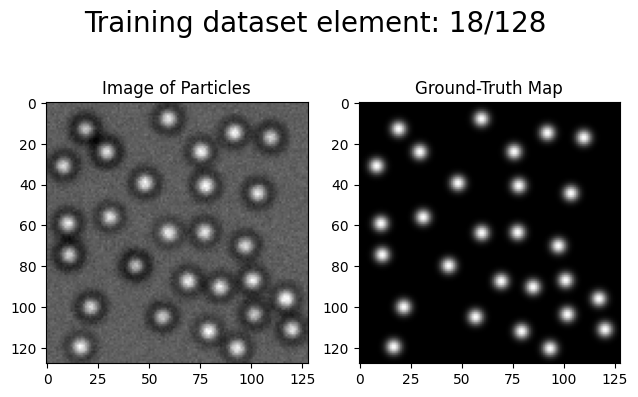

In [358]:
# Select an image and its corresponding ground truth maps and mask to show.
selected_image_index = np.random.randint(0, len(images))

# Extract the image and probability map from 4D arrays.
selected_image = np.squeeze(images[selected_image_index])
selected_probability_map = np.squeeze(maps[selected_image_index])

# Plot the image as the first subplot.
utils.plot_image_mask_ground_truth_map(
    image=selected_image,
    gt_map=selected_probability_map,
    title=f"Training dataset element: {selected_image_index+1}/{len(images)}",
)

### Define a U-Net model using Deeplay

The name 'U-Net' comes from its characteristic U-shaped architecture, which features a symmetric encoder–decoder structure. The encoder (downsampling path) captures contextual information by progressively reducing spatial resolution, while the decoder (upsampling path) restores spatial detail. Skip connections between corresponding levels of the encoder and decoder help retain fine-grained features, improving segmentation accuracy—especially for small or faint objects.

You'll define a 2D U-Net where both the input and output images have a single channel, corresponding to grayscale intensity. The goal is for the model to learn a mapping from the experimental image to a spatial probability density map that indicates the likelihood of particle presence at each pixel.

As a rule of thumb, stacking N convolutional layers with 3×3 kernels gives a receptive field of about (2N+1)×(2N+1) pixels. For example, three layers correspond to roughly a 7×7 receptive field.
Downsampling layers (like 2×2 pooling or stride-2 convolutions) expand the receptive field much more quickly, since each subsequent convolution “sees” a larger patch of the original image. This is why U-Nets with multiple downsampling stages can capture both fine details and large-scale context.

In [359]:
# Input and output channels are set to 1, since both images and probability
# maps only have one color channel.
unet = dl.UNet2d(
    in_channels=1, 
    channels=[16, 32, 64], 
    out_channels=1,
)

Compile the model for the task of regressing the masks from the images.

In [360]:
# A U-Net regressor is defined using a deeplay model. The loss function is Mean
# Squared Error Loss, since the output is a continuous intensity map.
regressor_unet = dl.Regressor(
    model=unet, 
    loss=torch.nn.MSELoss(), 
    optimizer=dl.Adam(lr=1e-3),
).create()

Define the training pipeline using Deeptrack to generate the training dataset
The training pipeline is composed of the simulated images and the probability maps, together with instructions of value normalization and a selector of images, all of which are instances of Deeplay.

In [361]:
# Image selector with a random picker. This is performed in order to properly 
# link an element in maps array with its corresponding element in images 
# array.
selector = dt.Lambda(
    lambda i: lambda x: x[i], i=lambda l: np.random.randint(l), l=len(images)
)

# Apply augmentations of added Gaussian noise only to images.
images_augmentation_pipeline = (
    dt.Value(images)
    >> dt.NormalizeMinMax(0.0, 1.0)
    >> dt.Gaussian(0.0, 0.015)
    >> dt.NormalizeMinMax(
        lambda: np.random.uniform(0.0, 0.0), 
        lambda: np.random.uniform(0.9, 1.0)
    )
)

# Apply normalization to ground truth map.
maps_pipeline = dt.Value(maps) >> dt.NormalizeMinMax(0.0, 1.0)

# Training pipeline consists of two paired lists: images and ground-truth maps.
# Images are augmented and normalized, while maps are only normalized.
# The selector randomly selects an image and its corresponding ground truth.
# The pipeline is then passed to the deeplay model.
pipeline = (
    (images_augmentation_pipeline & maps_pipeline)
    >> dt.FlipUD()
    >> dt.FlipLR()
    >> selector
)

# Create the training dataset instance in PyTorch
train_dataset = dt.pytorch.Dataset(pipeline, length=256)

Randomly select and display one augmented crop from the training dataset.

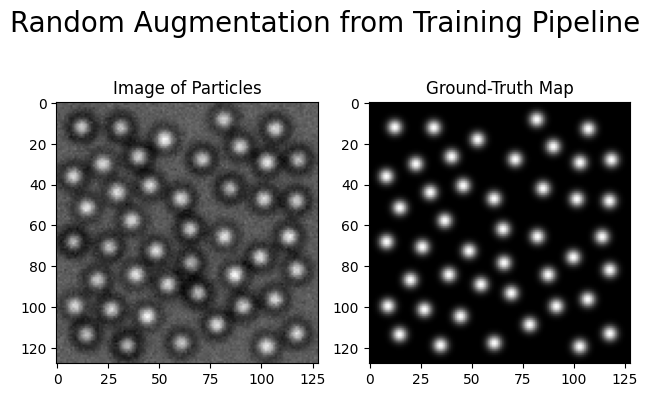

In [362]:
# Sanity check.
sanity_check_pipeline_augmentation = np.squeeze(pipeline.update().resolve())
sanity_check_image_augmentation = sanity_check_pipeline_augmentation[0]
sanity_check_map_augmentation = sanity_check_pipeline_augmentation[1]

# # Plot the image as the first subplot.
utils.plot_image_mask_ground_truth_map(
    image=sanity_check_image_augmentation,
    gt_map=sanity_check_map_augmentation,
    title=f"Random Augmentation from Training Pipeline",
)

### Train the U-Net model

Create a dataloader to iterate over the training dataset in batches ensuring randomized sampling at each epoch. Initialize a Trainer from Deeplay to train the U-Net model for up to 64 epochs.

In [363]:
from torch.utils.data import DataLoader

# Create a DataLoader for training.
train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True,
    )

# Initialize UNet trainer with automatic accelerator (e.g., CUDA if available).
trainer_unet = dl.Trainer(max_epochs=64, accelerator="auto")

Attempt to load pre-trained weights for the U-Net model. If the weights file does not exist, train the model from scratch and save the weights for future use.

Training U-Net model (either forced or weights not found).


c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ UNet2d           │  128 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 128 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 128 K                                                                                                
Total estimated model params size (MB): 0.513                                                                      
Modules in train mode: 42                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Saved trained U-Net weights to 'UNet/'.


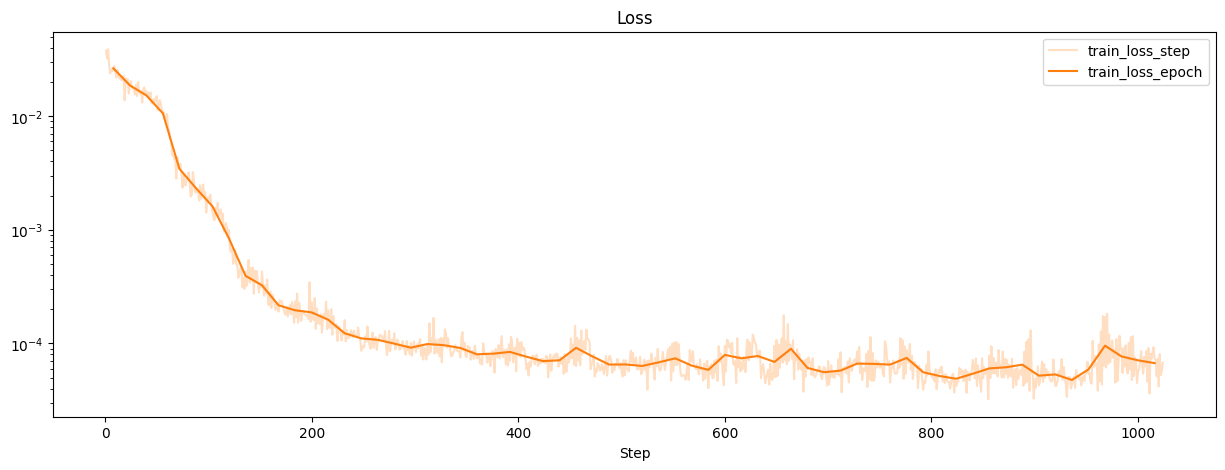

In [364]:
# Force training if desired
force_training = True

# Define the file paths for the model weights
unet_path = "UNet_model_core-shell.pth"
regressor_unet_path = "UNet_reg_core-shell.pth"

# Define the name of an enclosing folder and add it to the file path.
folder_name = "UNet"
unet_path = os.path.join(folder_name, unet_path)
regressor_unet_path = os.path.join(folder_name, regressor_unet_path)

# Load preexisting weights if they exist and training is not forced.
if (not force_training and os.path.exists(unet_path)
    and os.path.exists(regressor_unet_path)):
    unet.load_state_dict(torch.load(unet_path, weights_only=True))
    regressor_unet.load_state_dict(
        torch.load(regressor_unet_path, weights_only=True)
    )
    print(f"Loaded preexisting U-Net weights from '{folder_name}/'.")
else:
    print("Training U-Net model (either forced or weights not found).")
    
    # Ensure the save directory exists.
    os.makedirs(folder_name, exist_ok=True)

    # Train the U-Net model.
    trainer_unet.fit(regressor_unet, train_loader)
    
    # Monitor training history.
    trainer_unet.history.plot()

    # Save the weights.
    torch.save(unet.state_dict(), unet_path)
    torch.save(regressor_unet.state_dict(), regressor_unet_path)
    print(f"Saved trained U-Net weights to '{folder_name}/'.")

# Transfer the model to the best available device (optional).
regressor_unet.to(device);

### Apply the Trained U-Net to the Simulations

Use the trained U-Net to infer the probability map of the simulated image, leveraging the knowledge the model has learned. This output represents the predicted likelihood of particle presence at each pixel.

First, convert the selected image to a PyTorch tensor and pass it through the trained U-Net to infer the probability map of particle locations.

In [365]:
# Convert the image to analyze into a PyTorch tensor.
formatted_sim_image = utils.format_image(sim_image).to(device)

# Apply the UNet to the loaded image.
sim_image_pred_map_tensor = regressor_unet(formatted_sim_image)

# Convert to NumPy array.
sim_image_pred_map = sim_image_pred_map_tensor[0,0,:,:].cpu().detach().numpy()

# Normalize intensity.
sim_image_pred_map = utils.normalize_min_max(sim_image_pred_map)

Apply thresholding to the predicted probability map to isolate potential particle regions.

Calculate the centroids of the detected regions using the probability map as a weight. This enables subpixel localization by emphasizing the most confident regions of each detection. 

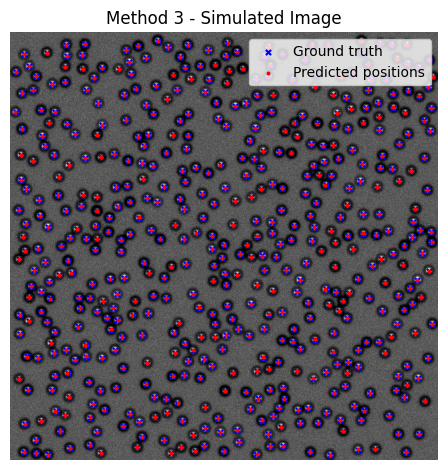

Found 519 detections.


In [366]:
# Apply thresholding to the predicted ground truth map.
sim_image_pred_mask_unet = sim_image_pred_map > 0.6

# Convert the masked ground truth map to positions.
sim_locs_pred_method3 = \
    utils.mask_to_positions(sim_image_pred_mask_unet, sim_image_pred_map)

# Show the predicted posiions and ground truth on the simulated image.
utils.plot_predicted_positions(
    image=sim_image,
    pred_positions=sim_locs_pred_method3, 
    gt_positions=sim_locs_gt,
    title="Method 3 - Simulated Image",
)
# Print the number of detections.
print(f"Found {len(sim_locs_pred_method3[:,1])} detections.")

Evaluate performance by comparing the predicted coordinates with ground-truth positions.

Visualize the results by displaying the original image with the localized particle positions overlaid, allowing you to qualitatively assess the accuracy of the prediction.

True Positives: 519/519
False Positives: 0
False Negatives: 0
F1 Score: 1.0000
RMSE: 0.1302


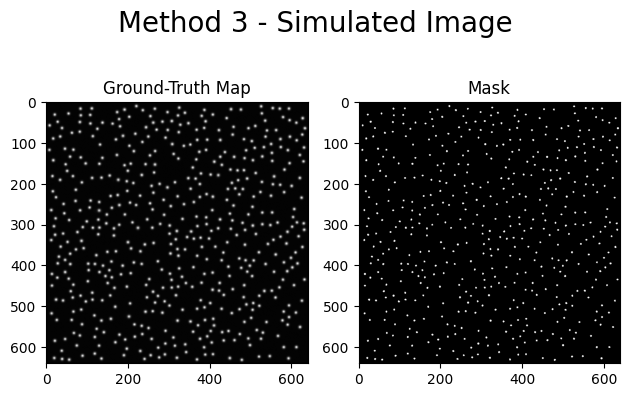

In [367]:
# Measure the performance.
utils.evaluate_locs(
    sim_locs_pred_method3, sim_locs_gt, distance_th=particle_radius,
);

# Plot the predicted ground truth map and its masked version.
utils.plot_image_mask_ground_truth_map(
    mask=sim_image_pred_mask_unet,
    gt_map=sim_image_pred_map,
    title="Method 3 - Simulated Image",
)

### Apply the Trained U-Net to the Experiments

Use the trained U-Net model to predict where particles are in the experimental image:

- Normalize the image so pixel values are between 0 and 1.
- Reshape the image to match the input format expected by the network: (N, C, X, Y) → where N=1 (batch size), and C=1 (grayscale).
- Convert the image to a PyTorch tensor and feed it to the U-Net.
- The model returns a probability map showing where it thinks particles are most likely to be.
- Normalize the predicted map again to scale between 0 and 1.
- Apply a threshold to the probability map to create a binary mask.
- Extract particle positions from this mask.
- Plot both the experimental image with predicted positions and the model's output map + masked version for inspection.

No ground truth positions were passed


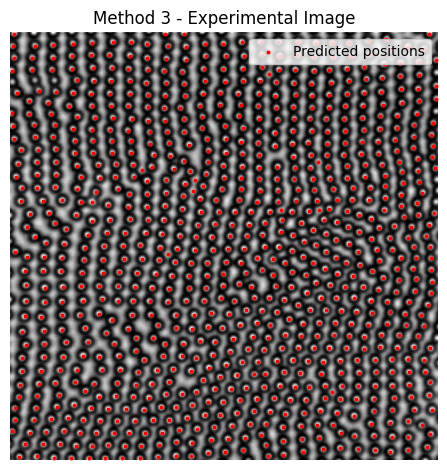

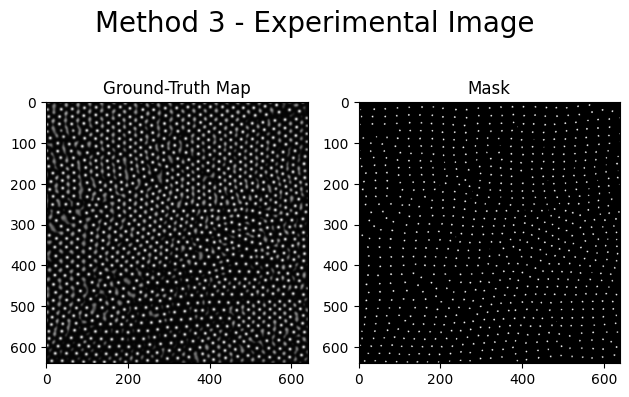

Found 817 detections.


In [371]:
# Convert the image to analyze into a PyTorch tensor.
formatted_exp_image = utils.format_image(exp_image[..., np.newaxis])

# Transfer the tensor to the best available device (optional).
formatted_exp_image = formatted_exp_image.to(device)

# Apply the UNet to the loaded image.
exp_image_pred_map_tensor = regressor_unet(formatted_exp_image)

# Convert to NumPy array.
exp_image_pred_map = exp_image_pred_map_tensor[0,0,:,:].cpu().detach().numpy()

# Normalize intensity.
exp_image_pred_map = utils.normalize_min_max(exp_image_pred_map)

# Apply thresholding to the predicted ground truth map.
exp_image_pred_mask_unet = exp_image_pred_map > 0.7

# Convert the masked ground truth map to positions.
exp_locs_pred_method3 = \
    utils.mask_to_positions(exp_image_pred_mask_unet, exp_image_pred_map)

# Plot the experimental image with the positions predicted by U-Net.
utils.plot_predicted_positions(
    image=exp_image, 
    pred_positions=exp_locs_pred_method3, 
    title="Method 3 - Experimental Image",
)

# Plot the predicted ground truth map and its masked version.
utils.plot_image_mask_ground_truth_map(
    mask=exp_image_pred_mask_unet,
    gt_map=exp_image_pred_map,
    title="Method 3 - Experimental Image",
)

# Print the number of detections.
print(f"Found {len(exp_locs_pred_method3[:,1])} detections.")

## Method 4: LodeSTAR

LodeSTAR is a self-supervised method for object detection that doesn’t require labeled data. You can even train it using a single input image—no manual annotations needed!

The idea is simple but powerful: LodeSTAR learns to detect particles by finding consistent features across randomly transformed versions of the same image. These transformations can include translation, rotation, or scaling.

By learning to predict the coordinate shifts between the transformed images, the network becomes very good at localizing objects—even under noisy or experimental conditions.

This makes LodeSTAR especially useful when ground-truth labels are unavailable or unreliable, which is often the case in real microscopy work.

### Simulate Training Data for LodeSTAR

To mimic real experimental conditions, we use DeepTrack to generate a set of synthetic images, each containing a single particle. These are produced using a mix of simulation and data augmentation. The particle’s size and intensity are randomized within realistic bounds, making the dataset more diverse and representative of what you'd expect in actual microscopy data.

This setup reflects real use cases, where LodeSTAR is trained on augmentations of a single experimental crop.

If the dataset already exists, you can simply load it; otherwise, new crops are simulated and saved.

Finally, a few sample crops are visualized to confirm they look physically realistic.

Generating sample 128/128
Dataset generation complete.
Generated and saved new dataset.


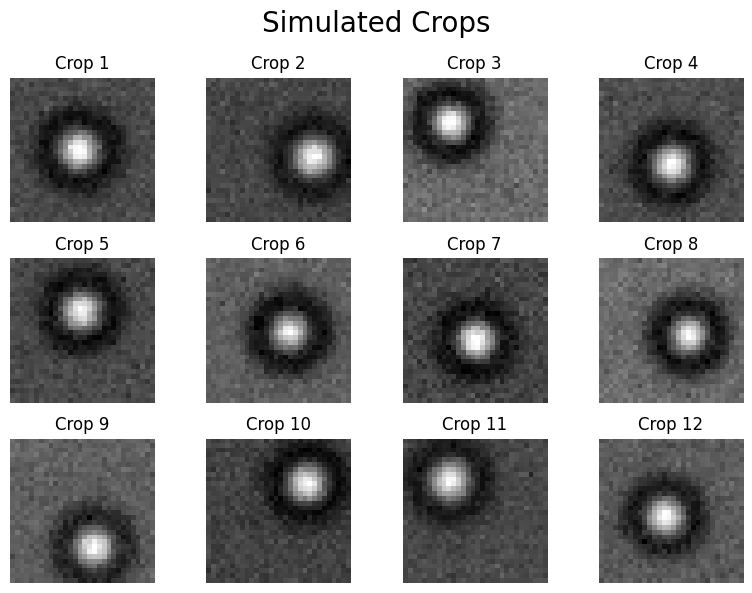

In [42]:
# Number of samples, image size, and particles.
num_samples = 128
train_crops_size = sim_crop_size
max_num_particles = 1
force_simulation = True  # Flag to force simulation even if data exists.

# Create path to store training dataset.
folder_name = "LodeSTAR"
training_dataset_filename = "LodeSTAR_training_dataset_core-shell.npz"
training_dataset_folder = os.path.join(folder_name, "training_data")
training_dataset_filepath = os.path.join(
    training_dataset_folder, 
    training_dataset_filename,
)

# Create the enclosing directory if not existent already.
os.makedirs(training_dataset_folder, exist_ok=True)
    
# Dictionaries for shell and core properties. Dimensions are set with lambda
# functions to introduce variety to the dataset.
core_particle_properties={
    "radius": lambda: (np.random.uniform(0.95, 1.05)
                       * core_radius * dt.units.nm),
    "intensity": lambda: np.random.uniform(200, 230),
    "z": lambda: np.random.normal(0, 100) * dt.units.nm,  # Particle in focus
    "refractive_index": 1.59  # Polystyrene
}

shell_particle_properties={
    "radius": lambda: (np.random.uniform(0.95, 1.05)
                       * shell_radius * dt.units.nm),
    "intensity": lambda: np.random.uniform(-55, -46),
    "refractive_index": 1.5  # PVA
}

# Set the optical properties of the microscope.
optics_properties = dt.Fluorescence(
    NA=0.6,  # Numerical aperture
    wavelength=638 * dt.units.nm, 
    refractive_index_medium=1.33, 
    output_region=[0, 0, train_crops_size, train_crops_size],
    magnification=1,
    resolution=pixel_size_nm * dt.units.nm,  # Camera effective resolution
)

# Try to load preexisting simulated data; if not available or forced, raise the
# exception error to generate new data.
try:
    if force_simulation: 
        # Raise the exception error if simulation is forced.
        raise FileNotFoundError("Forced simulation by user request.")
    
    if not os.path.isfile(training_dataset_filepath):
        # If file is not found, start training.    
        raise FileNotFoundError(
            "Training dataset file not found. Starting simulation."
        )
    
    # Load existing data
    data = np.load(training_dataset_filepath)
    crop_images = data["crop_images"]
    crop_maps = data["crop_maps"]
    Nsamples = len(crop_images)  # Update number of samples
    print(f"Loaded file: {training_dataset_filepath}")
        
# Handle the case of either file not found or forced training.
except FileNotFoundError:
    
    # Perform simulation if file not found or forced.
    crop_images, crop_maps = utils.generate_particle_dataset(
        num_samples=num_samples,
        fov_size=train_crops_size,
        max_num_particles=max_num_particles,
        core_particle_dict=core_particle_properties,
        shell_particle_dict=shell_particle_properties,
        optics_properties=optics_properties,
        background_props={"poisson_snr": 1500, "background_mean": 90},
    )   

    # Save the simulated training dataset.
    np.savez(
        training_dataset_filepath, 
        crop_images=crop_images, 
        crop_maps=crop_maps
    )
    print("Generated and saved new dataset.")
    
    # Plot up to 18 simulated crops.
utils.plot_crops(np.squeeze(crop_images), title="Simulated Crops")

Build a training pipeline that randomly selects and augments particle crops on the fly. Each crop is chosen randomly from the simulated dataset and normalized with slightly varying min/max values to mimic contrast and illumination changes.

This setup creates a diverse training set without needing to store multiple augmented copies.

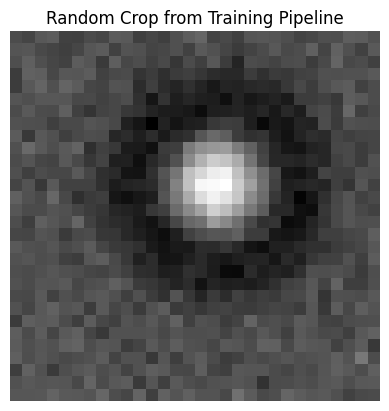

In [43]:
# Define the training pipeline with additional settings, such as multiplication
# of global intensity and Gaussian noise.
selector = dt.Lambda(
    lambda i: lambda x: x[i],
    i=lambda l: np.random.randint(l),
    l=len(crop_images),
)

# Define a training pipeline with augmentations. 
training_pipeline = (
    dt.Value(lambda: crop_images)
    >> dt.NormalizeMinMax(0.0, 1.0)
    >> dt.Gaussian(0.0, 0.015)
    >> dt.NormalizeMinMax(
        lambda: np.random.uniform(0.0, 0.1), 
        lambda: np.random.uniform(0.9, 1.0)
    )
    >> selector
)

# Build a training dataset with a pipeline that randomly selects a crop each
# time.
train_dataset = dt.pytorch.Dataset(
    training_pipeline,
    length=256,
)

# Dataloader contains the randomized training dataset and additional settings.
dataloader = dl.DataLoader(
    train_dataset,
    batch_size=8,
)

# We can check one of the elements in the training pipeline with augmentations.
sanity_check_crop = training_pipeline.update().resolve()

plt.figure()
plt.imshow(np.squeeze(sanity_check_crop), cmap="gray", aspect="equal")
plt.title("Random Crop from Training Pipeline")
plt.axis("off")
plt.show()

### Train LodeSTAR and Apply it to Simulations

Create a LodeSTAR model with 8 random geometric transformations per input and set up the trainer, which will handle the training loop.

In [44]:
#  Initialize the model.
lodestar = dl.LodeSTAR(
    n_transforms=8,
    optimizer=dl.Adam(lr=1e-3),
).build()

# Set up the trainer and specify number of epochs.
trainer_lodestar = dl.Trainer(max_epochs=64, accelerator="auto")

Check if pretrained weights already exist. Otherwise train LodeSTAR on the experimental crops using the training pipeline and save the trained weights for later use. Otherwise, simply load the existing weights from file.

Finally, switch the model to evaluation mode, which disables training-specific behaviors.

Training LodeSTAR model (either forced or weights not found).


c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:543: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1.004                                                                      
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\Aaron Domenzain\.conda\envs\PT_exp\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Saved LodeSTAR weights to 'LodeSTAR\lodestar_weights_simulated'.


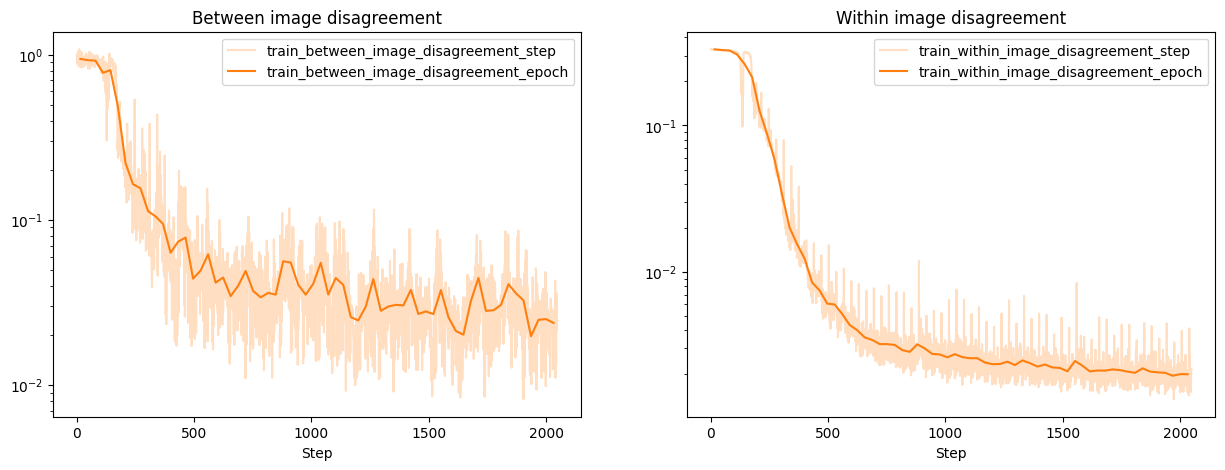

In [45]:
# Define whether to force training even if weights exist.
force_training = True

# Define folder and path for storing LodeSTAR weights.
folder_name = "LodeSTAR"
lodestar_path = os.path.join(folder_name, "lodestar_weights_simulated")

# Train or load weights.
if not os.path.isfile(lodestar_path) or force_training:
    print("Training LodeSTAR model (either forced or weights not found).")
    
    # Ensure the save directory exists.
    os.makedirs(folder_name, exist_ok=True)
    
    # Train the model.
    trainer_lodestar.fit(lodestar, dataloader)
    
    # Monitor training history.
    trainer_lodestar.history.plot()   
    
    # Save weights.
    torch.save(lodestar.state_dict(), lodestar_path)
    print(f"Saved LodeSTAR weights to '{lodestar_path}'.")
else:
    # Load pre-trained weights.
    lodestar.load_state_dict(torch.load(lodestar_path, weights_only=True))
    print(f"Loaded preexisting LodeSTAR weights from '{lodestar_path}'.")

# Set model to evaluation mode.
lodestar.eval();

# Transfer the model to the best available device (optional).
lodestar.to(device);

Apply the trained LodeSTAR model to a simulated image.  Set the inference parameters which control detection sensitivity. Get the prediction features, including the mass_feature, which can be useful for visualizing detections. Extract the final coordinates of the detected particles and print how many particles were detected.

In [46]:
# Parameters for inference.
alpha = 0.5
beta = 1 - alpha
cutoff = 0.7


# Extract predictions.
sim_image_pred_lodestar = \
    lodestar(formatted_sim_image.to(device)).squeeze().detach()

# Extract the mass feature from the prediction.
sim_image_mass_feature = sim_image_pred_lodestar[2].cpu()

# Infer on the pytorch image.
sim_locs_pred_method4 = lodestar.detect(
    formatted_sim_image,
    alpha = alpha,
    beta = beta, 
    mode = "quantile",
    cutoff = cutoff,
)[0]
                         
print(f"Found {len(sim_locs_pred_method4[:, 1])} detections.")

Found 524 detections.


Display predictions from the simulated image

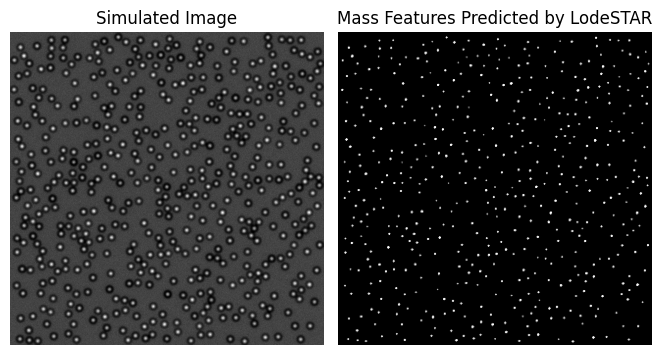

In [47]:
plt.figure(figsize=(10, 5))

#  Subfigure 1, test image.
plt.subplot(1, 3, 1)
plt.imshow(sim_image, cmap="gray")
plt.axis("off")
plt.title("Simulated Image")

#  Subfigure 2, mass feature distribution.
plt.subplot(1, 3, 2)
plt.imshow(sim_image_mass_feature, cmap="gray")
plt.axis("off")
plt.title("Mass Features Predicted by LodeSTAR")

plt.axis("off")
plt.tight_layout()
plt.show()

Plot the predicted positions from LodeSTAR alongside the ground truth on the simulated image and quantify the performance.

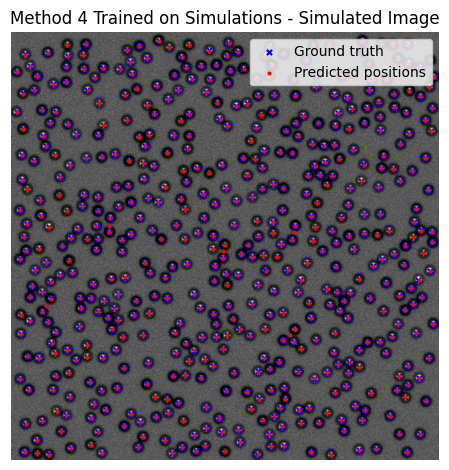

True Positives: 519/519
False Positives: 5
False Negatives: 0
F1 Score: 0.9952
RMSE: 0.1542


In [48]:
# Plot the predicted positions and the ground truth overlaid on the simulated
# image.
utils.plot_predicted_positions(
    image=sim_image,
    pred_positions=sim_locs_pred_method4,
    gt_positions=sim_locs_gt,
    title="Method 4 Trained on Simulations - Simulated Image",
)
#  Evaluate performance.
utils.evaluate_locs(
    sim_locs_pred_method4, sim_locs_gt, distance_th=particle_radius,
);

### Apply the Trained LodeSTAR on Experiments

- Apply LodeSTAR to the experimental image using the same inference settings (alpha, beta, cutoff) as before.
- Run the model to extract prediction features, including the mass channel.
- Get the final particle coordinates and print the total number of detections.
- Visualize the original experimental image and the mass feature map predicted by LodeSTAR.

Found 804 detections.


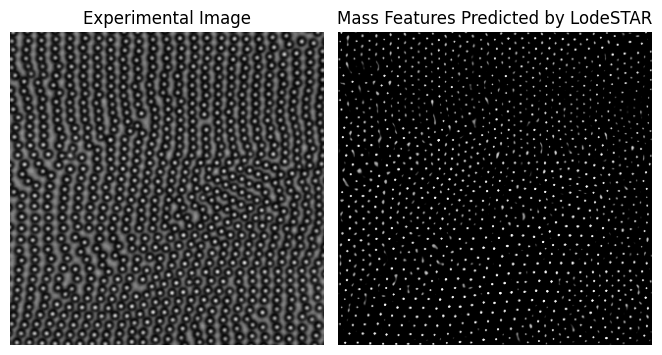

In [315]:
#  Parameters for inference.
alpha = 0.
beta = 1 - alpha
cutoff = 0.97

# Extract predictions and convert into a tensor
exp_image_pred_lodestar = \
    lodestar(formatted_exp_image.to(device)).squeeze().detach()

# Extract the mass feature from the prediction
exp_image_mass_feature = \
    exp_image_pred_lodestar[2].cpu()  # Transfer to CPU for plotting

# Infer positions from experimental image.
exp_locs_pred_method4 = lodestar.detect(
    formatted_exp_image,
    alpha = alpha,
    beta = beta, 
    mode = "quantile",
    cutoff = cutoff,
)[0]

print(f"Found {len(exp_locs_pred_method4[:,1])} detections.")

## Display predictions of experimental image
# Set the figure size
plt.figure(figsize=(10, 5))

#  Subfigure 1, test image.
plt.subplot(1, 3, 1)
plt.imshow(exp_image, cmap="gray")
plt.axis("off")
plt.title("Experimental Image")

#  Subfigure 2, mass features.
plt.subplot(1, 3, 2)
plt.imshow(exp_image_mass_feature, cmap="gray")
plt.axis("off")
plt.title("Mass Features Predicted by LodeSTAR")

plt.gca().set_aspect('equal', adjustable='box')
plt.axis("off")
plt.tight_layout()
plt.show()

Display the experimental image with the predicted particle positions overlaid to visually inspect the detection quality.

No ground truth positions were passed


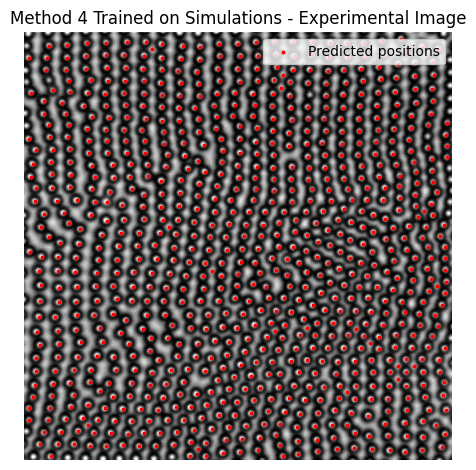

In [316]:
utils.plot_predicted_positions(
   image=exp_image,
   pred_positions= exp_locs_pred_method4,
   title="Method 4 Trained on Simulations - Experimental Image",
)

### Train LodeSTAR with Experiments

Since LodeSTAR is self-supervised, you can train it directly on experimental crops—no ground-truth labels needed.

Start by identifying a few representative particles in the experimental image. From these, extract small crops centered on the particles using the same code to get the first crop in this tutorial. These serve as the training data, and LodeSTAR learns by applying random transformations to these crops and predicting how the particle positions change.

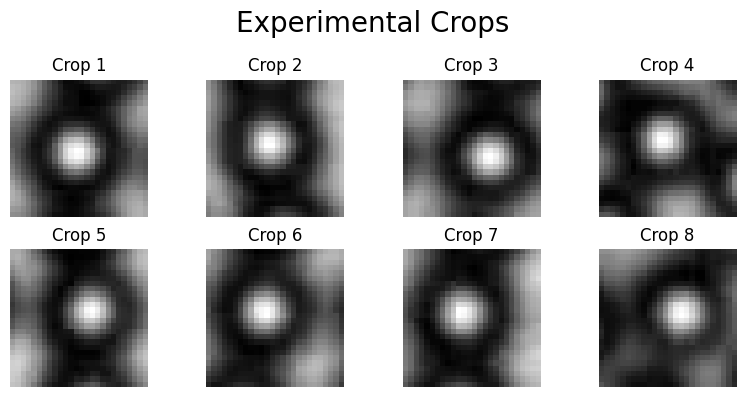

In [268]:
# Define crop parameters: (x, y, width)
exp_crop_size = 26

crop_params = (
    (285, 248,  exp_crop_size),
    (182, 181,  exp_crop_size),
    (184, 379,  exp_crop_size),
    (455, 347,  exp_crop_size),
    (473, 150,  exp_crop_size),
    (404,  57,  exp_crop_size),
    ( 35,  39,  exp_crop_size),
    (276, 539, exp_crop_size)
)

# Extract particle-centered crops from the image.
exp_crops = [exp_image[y - w//2:y + w//2, x - w//2:x + w//2, np.newaxis]
             for x, y, w in crop_params]

# Plot up to 18 crops.
utils.plot_crops(np.squeeze(exp_crops), title="Experimental Crops")

Prepare the training pipeline with the selected experimental crops.

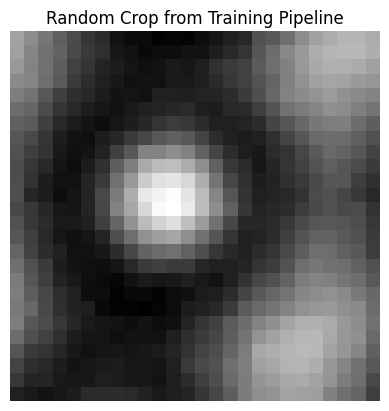

In [287]:
# Random selector of crops.
random_crop = lambda: random.choice(np.array(exp_crops))

# Define training pipeline.
training_pipeline = (
    dt.Value(random_crop)
    >> dt.NormalizeMinMax(0.0, 1.0)
    >> dt.Gaussian(0.0, 0.01)
    >> dt.NormalizeMinMax(
        lambda: np.random.uniform(0.0, 0.1), 
        lambda: np.random.uniform(0.9, 1.0),
        )
    # >> dt.FlipLR()
    # >> dt.FlipUD()
)

# Build a training dataset with a pipeline that randomly selects a crop each
# time.
train_dataset = dt.pytorch.Dataset(
    training_pipeline,
    length=256,
)

# Dataloader contains the randomized training dataset and additional settings.
dataloader = dl.DataLoader(
    train_dataset,
    batch_size=16,
)

# We can check one of the elements in the training pipeline with augmentations.
sanity_check_crop = training_pipeline.update().resolve()

plt.figure()
plt.imshow(np.squeeze(sanity_check_crop), cmap="gray")
plt.title("Random Crop from Training Pipeline")
plt.axis("off")
plt.show()

Create a LodeSTAR model with 4 random geometric transformations per input and set up the trainer, which will handle the training loop.

In [304]:
# Initialize the model.
lodestar_exp = dl.LodeSTAR(
    n_transforms=8, 
    optimizer=dl.Adam(lr=1e-3),
).build()

# Set up the trainer and specify number of epochs.
trainer_lodestar_exp = dl.Trainer(max_epochs=128, accelerator="auto")

Check whether pre-trained LodeSTAR weights already exist on disk. If they are missing or if training is explicitly forced, the model is trained on the experimental crops using the specified training pipeline, and the resulting weights are saved for future use.

If the weights are already available and training is not forced, they are simply loaded from file.

Afterward, the model is set to evaluation mode, which disables training-specific behaviors, ensuring consistent behavior during inference.

Training LodeSTAR on experimental data (either forced or weights not found).


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1.004                                                                      
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: |          | 0/? [00:00<?, ?it/s]

Saved experimental LodeSTAR weights to 'LodeSTAR\lodestar_weights_exp'.


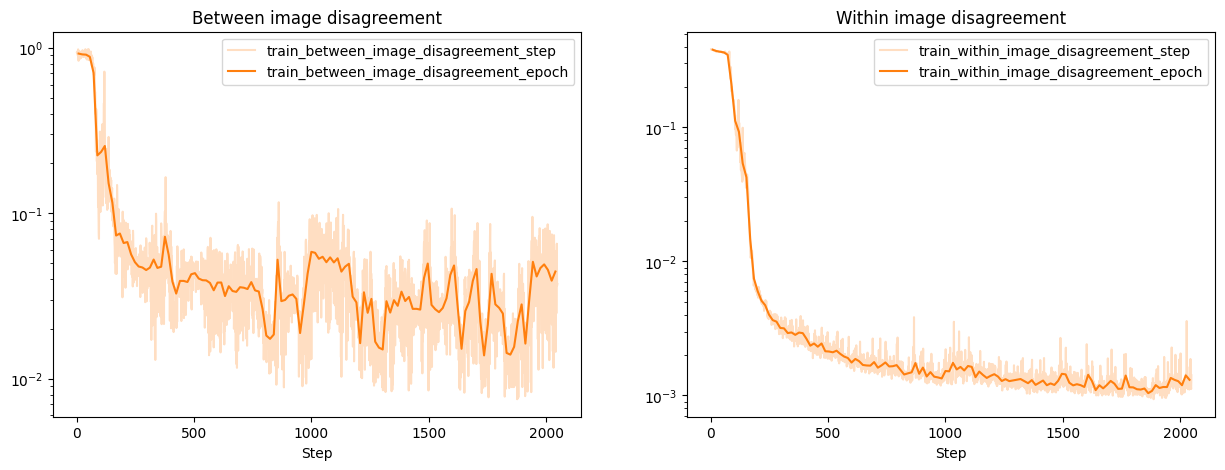

In [305]:
force_training = True

# Define folder and path for storing LodeSTAR experimental weights.
folder_name = "LodeSTAR"
lodestar_exp_path = os.path.join(folder_name, "lodestar_weights_exp")

# Train or load weights.
if not os.path.isfile(lodestar_exp_path) or force_training:
    print("Training LodeSTAR on experimental data "
          "(either forced or weights not found).")
    
    # Ensure the save directory exists.
    os.makedirs(folder_name, exist_ok=True)

    # Train the model.
    trainer_lodestar_exp.fit(lodestar_exp, dataloader)
    
    # Monitor training history.
    trainer_lodestar_exp.history.plot()

    # Save weights.
    torch.save(lodestar_exp.state_dict(), lodestar_exp_path)
    print(f"Saved experimental LodeSTAR weights to '{lodestar_exp_path}'.")
else:
    # Load pre-trained weights.
    lodestar_exp.load_state_dict(
        torch.load(lodestar_exp_path, weights_only=True)
    )
    print(f"Loaded preexisting LodeSTAR weights from '{lodestar_exp_path}'.")

# Set model to evaluation mode.
lodestar_exp.eval();

# Transfer the model to the best available device (optional).
lodestar_exp.to(device);

Apply the trained LodeSTAR model to an experimental image. Set the inference parameters which control detection sensitivity. Get the prediction features, including the mass_feature, which can be useful for visualizing detections. Extract the final coordinates of the detected particles and print how many particles were detected.

In [312]:
#  Parameters for inference.
alpha = 0.99
beta = 1 - alpha
cutoff = 0.65

#  Extract predictions and convert into a tensor.
exp_image_pred_lodestar_exp = \
    lodestar_exp(formatted_exp_image.to(device)).squeeze().detach()

# Extract the mass feature from the prediction.
exp_image_mass_feature_exp = \
    exp_image_pred_lodestar_exp[2].cpu()  # Transfer to CPU for plotting

#  Infer positions from experimental image.
exp_locs_pred_method4_exp = lodestar_exp.detect(
    formatted_exp_image,
    alpha=alpha,
    beta=beta, 
    mode="quantile",
    cutoff=cutoff,
)[0]
                         
print(f"Found {len(exp_locs_pred_method4_exp[:,1])} detections.")

Found 806 detections.


Display mass features predicted for the experimental image.

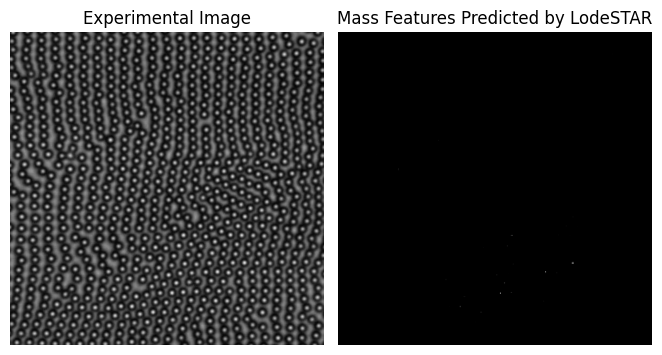

In [313]:
# Set the figure size.
plt.figure(figsize=(10, 5))

#  Subfigure 1, test image.
plt.subplot(1, 3, 1)
plt.imshow(exp_image, cmap="gray")
plt.axis("off")
plt.title("Experimental Image")

#  Subfigure 2, mass feature distribution.
plt.subplot(1, 3, 2)
plt.imshow(exp_image_mass_feature_exp, cmap="gray")
plt.axis("off")
plt.title("Mass Features Predicted by LodeSTAR")

plt.gca().set_aspect('equal', adjustable='box')
plt.axis("off")
plt.tight_layout()
plt.show()

Plot the predicted positions from LodeSTAR on the experimental image.

No ground truth positions were passed


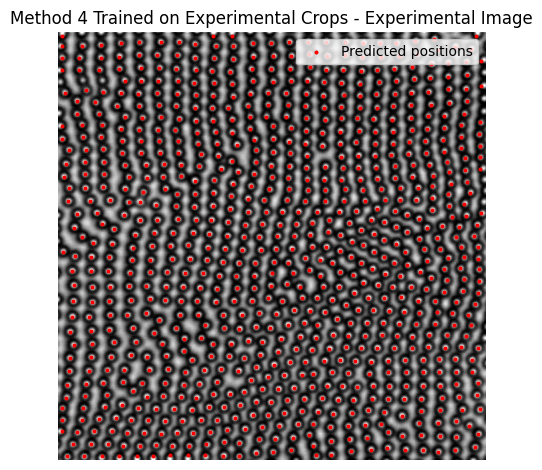

In [314]:
utils.plot_predicted_positions(
   image=exp_image,
   pred_positions= exp_locs_pred_method4_exp,
   title="Method 4 Trained on Experimental Crops - Experimental Image",
)